# 🧠 Train Latent Demand Recovery Model

> **Mục tiêu**: Huấn luyện mô hình phục hồi latent demand theo đúng paper:
> - Input: `observed_sales = hours_sale ⊙ hours_stock_status`
> - Output: `latent_demand` (24h)
> - Đánh giá bằng **Decoupling Score (ρDS)**
> - Lưu model vào Google Drive

In [1]:
!pip install pyarrow pandas numpy torch scikit-learn tqdm

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from google.colab import drive

drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/Colab Notebooks/datastorm/50k/data/"
model_save_path = "/content/drive/MyDrive/Colab Notebooks/datastorm/50k/model/"
os.makedirs(model_save_path, exist_ok=True)

Mounted at /content/drive


In [3]:
# Tải dữ liệu — nếu quá nặng, dùng subset
print("Đang tải dữ liệu...")
df_train = pd.read_parquet(data_path + 'train.parquet')

# Nếu > 1 triệu dòng → dùng 500K để demo
if len(df_train) > 1_000_000:
    df_train = df_train.sample(n=500_000, random_state=42).reset_index(drop=True)
    print(f"✅ Dùng subset: {len(df_train)} dòng")
else:
    print(f"✅ Dùng toàn bộ: {len(df_train)} dòng")

Đang tải dữ liệu...
✅ Dùng subset: 500000 dòng


In [4]:
# Chuẩn bị dữ liệu
print("Chuẩn bị dữ liệu...")
X, Y = [], []
for _, row in tqdm(df_train.iterrows(), total=len(df_train)):
    sales = np.array(row['hours_sale'])
    stock = np.array(row['hours_stock_status'])
    observed = sales * stock  # chỉ giữ sales khi có hàng

    feat = np.concatenate([
        observed,  # (24,)
        stock,     # (24,)
        [row['discount'], row['precpt'], row['holiday_flag'], row['avg_temperature']]
    ])
    X.append(feat)
    Y.append(sales)  # target = sales gốc (24h)

X = np.array(X)
Y = np.array(Y)

Chuẩn bị dữ liệu...


100%|██████████| 500000/500000 [00:31<00:00, 15749.80it/s]


In [5]:
# Chuẩn hóa (chỉ X)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
Y_scaled = Y  # không chuẩn hóa target

# Chuyển sang tensor
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
Y_tensor = torch.tensor(Y_scaled, dtype=torch.float32).to(device)

✅ Device: cuda


In [6]:
# Mô hình
class ImputationNet(nn.Module):
    def __init__(self, input_dim=52, output_dim=24, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, output_dim)
        )
    def forward(self, x):
        return self.net(x)

model = ImputationNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# DataLoader
dataset = TensorDataset(X_tensor, Y_tensor)
batch_size = 256 if device.type == 'cuda' else 64
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"✅ Batch size: {batch_size}")

✅ Batch size: 256


In [7]:
# Huấn luyện
epochs = 20
train_losses = []

print("Bắt đầu huấn luyện...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for xb, yb in tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.6f}")

Bắt đầu huấn luyện...


Epoch 1/20 | Loss: 0.009569


Epoch 2/20 | Loss: 0.009101


Epoch 3/20 | Loss: 0.008995


Epoch 4/20 | Loss: 0.008943


...

Epoch 16/20 | Loss: 0.008680


Epoch 17/20 | Loss: 0.008673


Epoch 18/20 | Loss: 0.008649


Epoch 19/20 | Loss: 0.008624


Epoch 20/20 | Loss: 0.008629


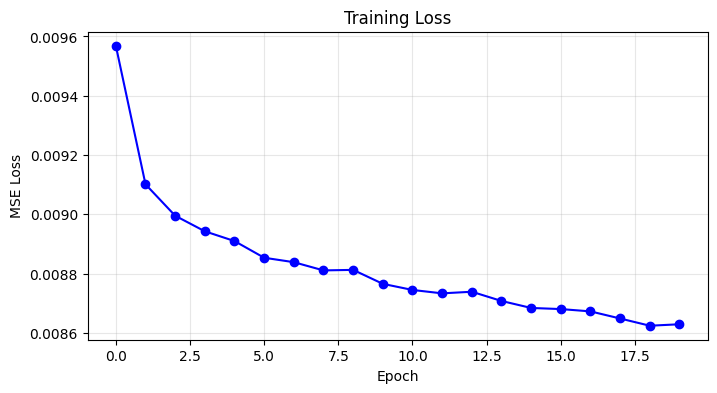

In [8]:
# Vẽ loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, 'b-o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# Tính ρDS (Decoupling Score)
print("Đang tính ρDS...")
model.eval()
with torch.no_grad():
    Y_pred = model(X_tensor).cpu().numpy()

# Post-process: demand >= 0
Y_pred = np.maximum(Y_pred, 0)

# Tính stockout ratio và demand trung bình (6h–22h)
stockout_ratios = []
avg_demands = []

df_sample = df_train.copy()
for i in tqdm(range(len(df_sample)), desc="Tính ρDS"):
    stock = np.array(df_sample.iloc[i]['hours_stock_status'])[6:23]
    sr = (stock == 0).mean()
    demand = Y_pred[i, 6:23].mean()
    stockout_ratios.append(sr)
    avg_demands.append(demand)

from scipy.stats import pearsonr
rho_ds, _ = pearsonr(stockout_ratios, avg_demands)
print(f"✅ Decoupling Score (ρDS): {rho_ds:.3f}")
print("→ Gần 0 = tốt. Paper (TimesNet): 0.07")

Đang tính ρDS...


Tính ρDS: 100%|██████████| 500000/500000 [00:44<00:00, 11333.77it/s]


✅ Decoupling Score (ρDS): 0.106
→ Gần 0 = tốt. Paper (TimesNet): 0.07


In [10]:
# Lưu model và scaler
print("Đang lưu model...")
torch.save(model.state_dict(), os.path.join(model_save_path, "latent_demand_model_final.pth"))
import pickle
with open(os.path.join(model_save_path, "scaler_X_final.pkl"), "wb") as f:
    pickle.dump(scaler_X, f)

print(f"✅ Đã lưu vào: {model_save_path}")

Đang lưu model...
✅ Đã lưu vào: /content/drive/MyDrive/Colab Notebooks/datastorm/50k/model/
